<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/GenPADS_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GenPADS: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/GenPADS](https://github.com/Mishrakshitij/GenPADS)   
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'GenPADS'
COMMIT = '2901ee109012fa086fe0b572a12fddbf6f89876b'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 2901ee109012fa086fe0b572a12fddbf6f89876b
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


In [ ]:
import gc
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForSeq2SeqLM

sys.path.insert(0, str(REPO_ROOT / "src"))
from genpads.data import verify_dataset, load_rows, dataset_path
from genpads.training import train_supervised, evaluate_checkpoint
from genpads.models import ResponseGenerator

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(2)
torch.manual_seed(42)
COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
print("Repository: https://github.com/Mishrakshitij/GenPADS")
print("Commit:", COMMIT)
print("Runtime:", DEVICE, "| PyTorch:", torch.__version__)

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: https://github.com/Mishrakshitij/GenPADS
Commit: 2901ee109012fa086fe0b572a12fddbf6f89876b
Runtime: cuda | PyTorch: 2.13.0+cu129


Verified CSV files: 28 | Conversation IDs: 17289


task,gendd/cleaned,gendd/dg,gendd/g,padd
domain,,,,
flights,28961,8003,16006,63346
food-ordering,6556,2076,4152,13953
hotels,27299,6373,12746,63048
movies,25551,8274,16548,59757
music,12475,4085,8170,26912
restaurant-search,25708,7089,14178,66205
sports,26118,9532,19064,48580


,conversation_id,example_id,input_text,target_text,split
0,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f_0_2,Hello. I'd like to find a round trip commercia...,"San Francisco to Denver, got it.",validation
1,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f_6_9,"I'm looking to fly out sometime today, the ear...",That's right okay we have prices starting at $...,validation
2,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f_10_14,That sounds very good. I just have two prefere...,"Okay, Non-Stop and if I heard you correctly di...",validation
3,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f,dlg-00100680-00e0-40fe-8321-6d81b21bfc4f_17_19,And what time will I be I would like an evenin...,How does 5:30 a.m. work?,validation


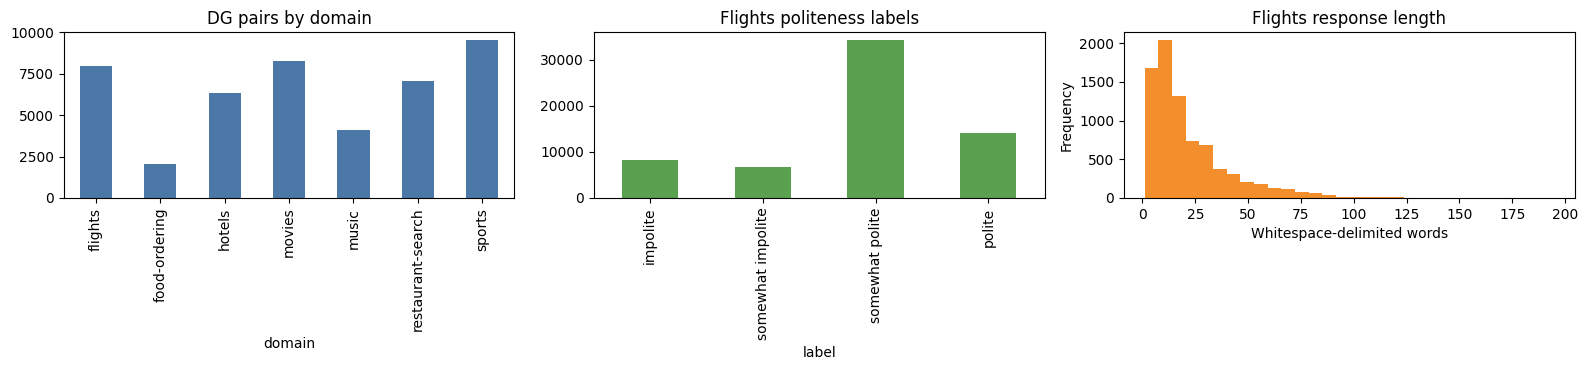

Flights DG records: 8003


In [ ]:
verification = verify_dataset(REPO_ROOT / "datasets")
assert verification["verified"] and verification["files"] == 28
print("Verified CSV files:", verification["files"], "| Conversation IDs:", verification["conversations"])
overview = pd.DataFrame([{"file": name, "rows": count} for name, count in verification["rows"].items()])
overview["task"] = overview["file"].str.rsplit("/", n=1).str[0]
overview["domain"] = overview["file"].str.rsplit("/", n=1).str[1].str.removesuffix(".csv")
display(overview.pivot(index="domain", columns="task", values="rows"))
data = pd.read_csv(REPO_ROOT / "datasets/gendd/dg/flights.csv", keep_default_na=False)
politeness = pd.read_csv(REPO_ROOT / "datasets/padd/flights.csv", keep_default_na=False)
display(data.head(4))
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
overview.loc[overview["task"].eq("gendd/dg")].set_index("domain")["rows"].plot.bar(ax=axes[0], color="#4C78A8", title="DG pairs by domain")
politeness["label"].value_counts().sort_index().rename(index={0: "impolite", 1: "somewhat impolite", 2: "somewhat polite", 3: "polite"}).plot.bar(ax=axes[1], color="#59A14F", title="Flights politeness labels")
data["target_text"].str.split().str.len().plot.hist(ax=axes[2], bins=30, color="#F28E2B", title="Flights response length")
axes[2].set_xlabel("Whitespace-delimited words")
plt.tight_layout()
plt.show()
print("Flights DG records:", len(data))

In [ ]:
chosen = {split: data.loc[data["split"].eq(split)].head(count).copy()
          for split, count in [("train", 10), ("validation", 4), ("test", 4)]}
assert [len(chosen[key]) for key in ("train", "validation", "test")] == [10, 4, 4]
members = {split: set(frame["conversation_id"]) for split, frame in chosen.items()}
assert not (members["train"] & members["validation"] or members["train"] & members["test"] or members["validation"] & members["test"])
subset_root = OUTPUT_DIR / "subset"
subset_path = subset_root / "gendd/dg/flights.csv"
subset_path.parent.mkdir(parents=True, exist_ok=True)
pd.concat(chosen.values(), ignore_index=True).to_csv(subset_path, index=False)
display(pd.DataFrame([{"split": split, "available": int(data["split"].eq(split).sum()), "selected": len(rows)} for split, rows in chosen.items()]))

,split,available,selected
0,train,6500,10
1,validation,755,4
2,test,748,4


In [ ]:
baseline = AutoModelForSeq2SeqLM.from_pretrained(SEQ2SEQ_MODEL)
initial = {name: value.detach().cpu().clone() for name, value in baseline.named_parameters()}
parameter_count = sum(parameter.numel() for parameter in baseline.parameters())
del baseline
gc.collect()
print("Hugging Face model:", SEQ2SEQ_MODEL, "| Parameters:", f"{parameter_count:,}")
checkpoint = OUTPUT_DIR / "checkpoint"
training = train_supervised("dg", "flights", checkpoint, data_root=subset_root,
                            model_name=SEQ2SEQ_MODEL, epochs=1, batch_size=2,
                            max_steps=5, max_length=48, learning_rate=5e-4,
                            accumulation_steps=1, device=DEVICE, seed=42)
assert training["optimizer_steps"] == 5
assert math.isfinite(training["best_validation_loss"])
assert (checkpoint / "config.json").is_file() and (checkpoint / "genpads.json").is_file()
assert any(checkpoint.glob("*.safetensors"))
display(pd.DataFrame(training["history"]))

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Hugging Face model: hf-internal-testing/tiny-random-bart | Parameters: 26,768


{"epoch": 1, "optimizer_steps": 5, "validation": {"examples": 4, "targets": 110, "loss": 6.899226795543324, "perplexity": 991.5077809095446}}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


,epoch,optimizer_steps,validation
0,1,5,"{'examples': 4, 'targets': 110, 'loss': 6.8992..."


In [ ]:
generator = ResponseGenerator(checkpoint, device=DEVICE, max_length=12, num_beams=1, do_sample=False)
parameter_delta = sum(float((value.detach().cpu() - initial[name]).abs().sum()) for name, value in generator.model.named_parameters())
assert parameter_delta > 0
recheck = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)
max_reload_difference = max(float((value.detach().cpu() - recheck.state_dict()[name].detach().cpu()).abs().max()) for name, value in generator.model.state_dict().items())
assert max_reload_difference == 0
del recheck, initial
gc.collect()
metrics = evaluate_checkpoint(checkpoint, data_root=subset_root, split="test", device=DEVICE, batch_size=2, text_metrics=False)
assert metrics["examples"] == 4 and math.isfinite(metrics["loss"]) and math.isfinite(metrics["perplexity"])
generated = generator.generate(chosen["test"]["input_text"].tolist())
assert len(generated) == 4
predictions = [{"example_id": str(row.example_id), "input": row.input_text, "reference": row.target_text, "prediction": prediction}
               for row, prediction in zip(chosen["test"].itertuples(index=False), generated)]
display(pd.DataFrame([metrics]))
display(pd.DataFrame(predictions))
result = {"project": "GenPADS", "status": "PASS", "scope": "native flights DG seq2seq generator",
          "model": SEQ2SEQ_MODEL, "commit": COMMIT, "parameters": parameter_count,
          "updates": training["optimizer_steps"], "counts": {"train": 10, "validation": 4, "evaluation": 4},
          "metrics": metrics, "training_history": training["history"],
          "parameter_l1_change": parameter_delta, "reload_max_abs_difference": max_reload_difference,
          "dataset_integrity": "PASS", "dataset_rows": int(overview["rows"].sum()),
          "checkpoints": ["checkpoint"], "predictions": predictions,
          "limitations": ["Only flights DG is trained; other domains, PC, G, and RL policy are not exercised.",
                          "Five-step tiny-model execution does not establish converged quality or reproduce paper results."]}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print("PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.")

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


,task,domain,split,examples,targets,loss,perplexity
0,dg,flights,test,4,144,6.911037,1003.287346


,example_id,input,reference,prediction
0,dlg-0027f924-7723-48bc-bf18-e41c03b0e709_1_2,"Hi, I need to find a flight from JFK to Seattle.",Okay from JFK to seattle.,
1,dlg-0027f924-7723-48bc-bf18-e41c03b0e709_5_8,I would like to fly on April 1st and return on...,"Alright, there are plenty of flights with Delt...",
2,dlg-0027f924-7723-48bc-bf18-e41c03b0e709_9_26,Excellent. I would like the economy. And I wou...,I see that there is one flight on April 1st wh...,
3,dlg-0027f924-7723-48bc-bf18-e41c03b0e709_27_34,"I will take the 10:15 AM, please.","Okay, 10:15 AM. You will arrive back in JFK at...",


PASS: dataset checks, native model load, five optimizer updates, save/reload, and four-example evaluation.


## Project summary

**Result: PASS for the tested configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved, reloaded and used for **recorded above held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.